# Getting started with `glori`: generating simulated LOFAR skies

This notebook is a hands-on introduction to sampling **simulated radio survey maps** with the pretrained latent diffusion model (LDM) from this repository. It covers:

1. Loading the pretrained VQ-VAE + denoiser and sampling one unconditional patch.
2. Controlling *where* sources appear (and their brightness/size) via a catalog context.
3. Sampling a map larger than a single patch with SWIIT sampling.
4. A quick reference for the sampling parameters.

Background: T. Vicánek Martínez and M. Brüggen (2026), *"Generating radio continuum survey maps of arbitrary size with latent diffusion models"*, A&A, [arXiv:2609.06549](https://arxiv.org/abs/2609.06549). See the repository `README.md` for an overview of the codebase and known gotchas.

## 0. Setup

Checkpoints and the scaler download automatically from the public Hugging Face repo
[`astrokevin/glori-ldm-swiit`](https://huggingface.co/astrokevin/glori-ldm-swiit) the first
time this runs, via `glori.hub.download_pretrained`, and are cached locally afterwards
(standard `huggingface_hub` cache, `~/.cache/huggingface/hub`). You do **not** need
`STORAGE_PARENT` / `settings/paths.py` set up for anything in this notebook.

If you're on the group's own cluster storage and would rather use the local copies
directly (no network needed), replace the three `download_pretrained(...)` calls below
with explicit paths under `STORAGE_PARENT` instead.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from glori.config.swiit_config import SWIITSamplerConfig
from glori.inference.swiit_sampler import SWIITSampler
from glori.data.trf.scalers import LOFARScaler
from glori.hub import download_pretrained

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

DENOISER_CKPT = download_pretrained("denoiser")
VAE_CKPT = download_pretrained("vae")
SCALER_PATH = download_pretrained("scaler")

/hs/fs08/data/group-brueggen/tmartinez/envs/cenv_glori/lib/python3.11/site-packages/stringcolor/main.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using device: cuda:0

In [2]:
def plot_map(img, title="", ax=None, cmap="inferno"):
    img = np.asarray(img)
    if img.ndim == 3:  # drop a leading batch/channel dim of size 1, if present
        img = img.squeeze()
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(5, 5))
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    if created_fig:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.show()
    return im

## 1. Unconditional sampling

The simplest possible use case: generate a synthetic sky patch from pure Gaussian noise, with no source catalog at all. `SWIITSamplerConfig` describes both the models to load and the sampling geometry; `SWIITSampler` does the work.

`sampling_steps=(2, 2)` is the smallest valid SWIIT grid. Note that even this minimum grid already stitches two overlapping 512px patches together (with the default 50% overlap, `mask_coverage=0.5`), so the output is larger than one raw patch: `image_size + (steps-1) * img_stride` = `512 + 1*256` = **768px** per side. (For a single, un-stitched 512px patch, use `LDMSampler` instead — see Section 4.)

With `ctxt_map=None`, the sampler fills the catalog context with zeros — matching how "no information available here" was represented during training (context outside the training crop, or randomly dropped during training, was zero-filled; see the paper's Section 3.1), so this produces a plausible unconditional sky.

In [3]:
config = SWIITSamplerConfig(
    denoiser="unused",  # ignored: a "/" in *_ckpt below bypasses model-name lookup
    denoiser_ckpt=DENOISER_CKPT,
    vae="unused",
    vae_ckpt=VAE_CKPT,
    device=DEVICE,
    # image_size=512, f_vae=4 (-> latent_size=128) are the defaults, matching
    # both checkpoints above; only change these if you're using different models.
)
sampler = SWIITSampler(config=config)

# The sampler's own scaler is loaded via settings.paths; override it with the
# downloaded copy instead.
sampler.scaler = LOFARScaler(**torch.load(SCALER_PATH, weights_only=False))

 21:41:36 (SWIITSampler)

 - 

INFO 

: Overriding config with provided kwargs...

 21:41:36 (SWIITSampler)

...

: Initializing diffusion sampler...

 21:41:40 (SWIITSampler)

 - 

INFO 

: ICM Sampler initialized.

In [4]:
torch.manual_seed(0)

map_image, latent_map = sampler.sample(sampling_steps=(2, 2), timesteps=25)
physical_map = sampler.scaler.inverse_scale(map_image)  # back to Jy/beam-like units

 21:41:40 (SWIITSampler)

 - 

INFO 

: Preparig context map...

 21:41:40 (SWIITSampler)

...

 21:42:13 (SWIITSampler)

 - 

INFO 

: Decoding latents...

Decoding latents:   0%|          | 0/4 [00:00<?, ?step/s]

map_image shape:

(1, 768, 768)

 (batch, height, width)

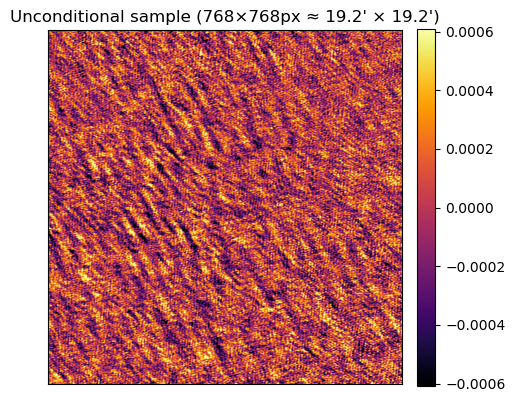

In [ ]:
side_px = physical_map.shape[-1]
side_arcmin = side_px * 1.5 / 60  # 1.5" per pixel
print("map_image shape:", map_image.shape, " (batch, height, width)")
plot_map(physical_map[0], title=f"Unconditional sample ({side_px}×{side_px}px ≈ {side_arcmin:.1f}' × {side_arcmin:.1f}')")

## 2. Controlling sources with a catalog context

The denoiser was trained with an additional conditioning input, the **catalog context vector**: a 4-channel, latent-resolution image where, at each source's pixel location,

- channel 0 is `+1` (and `-1` everywhere else — this marks *presence*, not just position),
- channel 1 is the source's total flux, in **raw, unscaled mJy**,
- channel 2 is its peak flux, in **raw, unscaled mJy**,
- channel 3 is its major-axis size, in **raw, unscaled arcsec**,

matching how the real training data is built (`glori.data.obs.micromaps.utils.context_map_by_wcs`, whose default `scale_output=False` leaves these three channels as the catalog's raw values). The `ctxt_scaler_*` files under `scalers/` are a separate, optional transform (Box-Cox + standardization) used only by a couple of hand-constructed-context helpers elsewhere (`LDMSampler.dice_context`/`explorer_context`) — not by the array format the model was actually trained on, and not needed here.

**A note on source footprint size**: a real source's signal, after the VQ-VAE's 4x downsampling, still spans a few latent pixels (not just one) — the restoring beam alone is close to one latent pixel wide. Marking only a single hard-edged latent pixel as "source here" is a weaker, less in-distribution signal than a small multi-pixel block; we use a 3x3 block below.

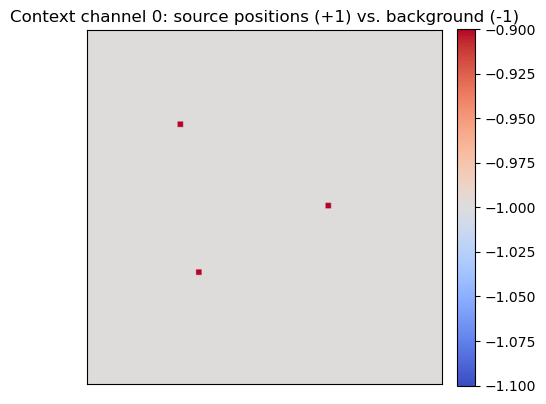

In [5]:
# For sampling_steps=(2, 2) with latent_size=128 and the default stride (64px),
# the latent map is 128 + (2-1)*64 = 192px per side. SWIITSampler infers the
# sampling grid from the context map's shape, so we don't need to pass
# sampling_steps explicitly below.
LATENT_MAP_SIZE = 192

ctxt_map = torch.zeros(4, LATENT_MAP_SIZE, LATENT_MAP_SIZE)
ctxt_map[0] = -1  # -1 = "no source at this pixel", everywhere by default

# (row, col, total_flux_mJy, peak_flux_mJy, major_axis_arcsec) -- bright,
# clearly-detectable sources; each placed as a 3x3 latent-pixel block (see
# the note above on why a single pixel is a weaker signal). Values are RAW
# physical units -- unlike the position channel, the flux/size channels are
# not passed through a scaler (see note above).
sources = [
    (60, 60, 80.0, 50.0, 20.0),    # bright, moderately extended
    (96, 130, 150.0, 90.0, 30.0),  # very bright, extended
    (140, 50, 40.0, 30.0, 12.0),   # moderately bright, more compact
]
for row, col, ftot, fpeak, maj in sources:
    r0, r1, c0, c1 = row - 1, row + 2, col - 1, col + 2  # 3x3 block
    ctxt_map[0, r0:r1, c0:c1] = 1.0
    ctxt_map[1, r0:r1, c0:c1] = ftot
    ctxt_map[2, r0:r1, c0:c1] = fpeak
    ctxt_map[3, r0:r1, c0:c1] = maj

plot_map(ctxt_map[0], title="Context channel 0: source positions (+1) vs. background (-1)", cmap="coolwarm")

In [6]:
torch.manual_seed(0)

cond_map_image, cond_latent_map = sampler.sample(ctxt_map=ctxt_map, timesteps=25)
cond_physical_map = sampler.scaler.inverse_scale(cond_map_image)

 21:42:15 (SWIITSampler)

 - 

INFO 

: Preparig context map...

 21:42:15 (SWIITSampler)

...

 21:42:47 (SWIITSampler)

 - 

INFO 

: Decoding latents...

Decoding latents:   0%|          | 0/4 [00:00<?, ?step/s]

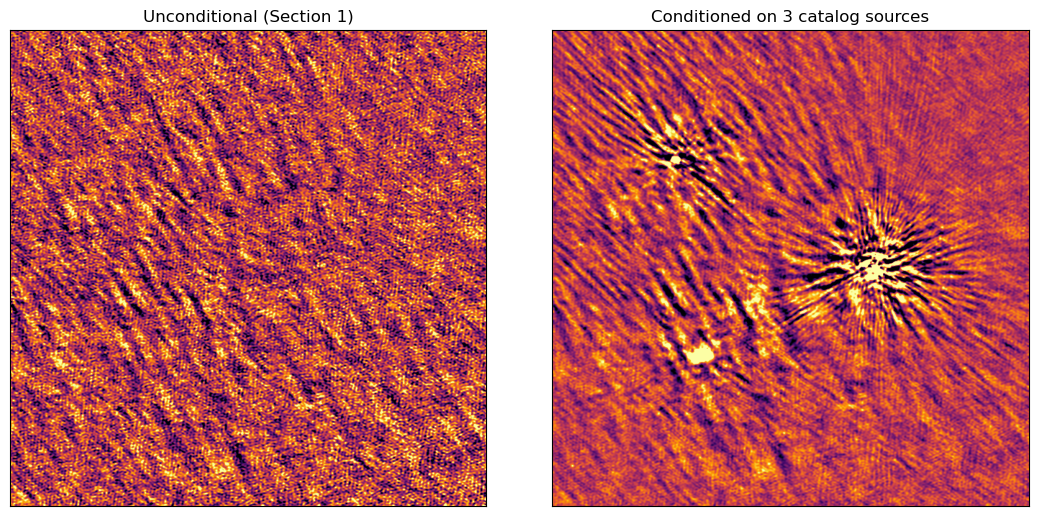

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
plot_map(physical_map[0], title="Unconditional (Section 1)", ax=axes[0])
plot_map(cond_physical_map[0], title="Conditioned on 3 catalog sources", ax=axes[1])
plt.tight_layout()
plt.show()

## 3. A realistic example: conditioning on a real LoTSS catalog

The three hand-placed sources above make the conditioning mechanism easy to see, but they're far sparser than any real field — that's also a big part of why the toy example above looks a lot emptier/noisier than the maps shown in the paper. The paper's own qualitative figures (Figs. 11-13) condition on catalog context vectors extracted from real LoTSS-DR3 fields, with dozens of sources per patch (paper Section 6.2).

LoTSS-DR3 is a public survey ([lofar-surveys.org/dr3.html](https://lofar-surveys.org/dr3.html)), so rather than relying on the group's internal, unpublished pre-encoded test split, this section builds a real context map from scratch using only the public archive — the same way the model's training data itself is built:

1. Fetch a real image cutout from the [DR3 cutout API](https://lofar-surveys.org/cutout_api_details.html).
2. Fetch the matching real source catalog from the [DR3 cone-search service](https://vo.astron.nl/lotss_dr3/q/src_cone/info).
3. Build the catalog context map with the same functions the training data pipeline uses (`glori.data.obs.micromaps.utils.context_map_by_wcs` + `reduce_context_map`), instead of hand-placing a few sources.

This runs from any machine with internet access — no cluster storage needed — and, unlike Section 2's toy example, only ever marks a single latent pixel per source (no artificial 3×3 dilation), matching what the model actually saw during training.

In [ ]:
import io
import requests
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table

from glori.data.obs.micromaps.utils import context_map_by_wcs, reduce_context_map
from glori.data.trf.functional import catalog_context_pos_rescale

CUTOUT_URL = "https://lofar-surveys.org/dr3-cutout.fits"
CONE_SEARCH_URL = "https://vo.astron.nl/lotss_dr3/q/src_cone/scs.xml"
PIXEL_SCALE_ARCSEC = 1.5  # native LoTSS-DR3 6" mosaic pixel scale


def fetch_real_context(ra_deg, dec_deg, latent_map_size, f_vae=4):
    """
    Fetch a real LoTSS-DR3 cutout + matching source catalog from the public
    archive, and build a catalog context map the same way the model's
    training data is built (context_map_by_wcs + reduce_context_map) --
    instead of the group's internal, unpublished pre-encoded dataset.
    """
    raw_size_px = latent_map_size * f_vae
    size_arcmin = raw_size_px * PIXEL_SCALE_ARCSEC / 60

    # Real image cutout
    resp = requests.get(
        CUTOUT_URL, params={"pos": f"{ra_deg} {dec_deg}", "size": size_arcmin}, timeout=60
    )
    resp.raise_for_status()
    with fits.open(io.BytesIO(resp.content)) as hdul:
        image = hdul[0].data.astype("float32")
        wcs = WCS(hdul[0].header).celestial

    # Matching real catalog. Search radius is generous -- context_map_by_wcs
    # filters sources down to the exact cutout footprint anyway.
    search_radius_deg = size_arcmin / 60 * 0.8
    resp = requests.get(
        CONE_SEARCH_URL,
        params={"RA": ra_deg, "DEC": dec_deg, "SR": search_radius_deg, "MAXREC": 20000},
        timeout=60,
    )
    resp.raise_for_status()
    cat = Table.read(io.BytesIO(resp.content), format="votable").to_pandas()
    # context_map_by_wcs expects Total_flux/Peak_flux/Maj columns (raw mJy,
    # mJy, arcsec -- see Section 2's note on units). We use Majax, the
    # *as-observed* (beam-included) major axis, not the deconvolved DC_Maj --
    # inferred from the internal training catalog's ".srl" naming (standard
    # PyBDSF source-list convention), not independently verified against the
    # training code. If generated source sizes look systematically off vs.
    # real ones, try DC_Maj instead.
    cat = cat.rename(columns={"Majax": "Maj"})
    cat = cat.dropna(subset=["RA", "DEC", "Total_flux", "Peak_flux", "Maj"])
    # filter_catalog_by_wcs does a sorted-DEC binary search internally (same
    # precondition as glori.data.load.load_lotss_catalog) -- on unsorted
    # input it silently returns a near-arbitrary subset instead of raising.
    cat = cat.sort_values(by="DEC")

    # Build the context map exactly like the training data pipeline: a
    # raw-native-pixel-resolution map from the catalog + WCS (single pixel
    # per source, no dilation), pooled down to latent resolution.
    raw_ctxt, sub_cat = context_map_by_wcs(wcs, cat, scale_output=False)
    ctxt_map = reduce_context_map(torch.as_tensor(raw_ctxt).float(), f_downscale=f_vae)
    ctxt_map = catalog_context_pos_rescale(ctxt_map)  # channel 0: {0,1} -> {-1,+1}

    return image, wcs, ctxt_map, sub_cat


# 256 latent px (1024 raw px, 25.6') -- big enough that SWIITSampler infers a
# 3x3 SWIIT grid automatically from ctxt_map.shape, so this doubles as a
# preview of Section 4's multi-patch stitching.
REAL_MAP_LATENT_SIZE = 256

# A real field, not cherry-picked for source density -- pick your own RA/Dec
# (degrees) to try a different one; https://lofar-surveys.org/dr3.html has
# the full DR3 footprint (88% of the northern sky).
RA, DEC = 170.0, 55.0

real_npy, real_wcs, real_ctxt_map, real_sub_cat = fetch_real_context(
    RA, DEC, latent_map_size=REAL_MAP_LATENT_SIZE
)
n_sources = int((real_ctxt_map[0] > 0).sum())
src_flux = real_ctxt_map[1][real_ctxt_map[1] > 0]
print(f"Real catalog context for RA={RA}, DEC={DEC}: {n_sources} sources, "
      f"flux range {float(src_flux.min()):.1f}-{float(src_flux.max()):.1f} mJy")

In [ ]:
torch.manual_seed(0)

real_map_image, real_latent_map = sampler.sample(ctxt_map=real_ctxt_map, timesteps=25)
real_physical_map = sampler.scaler.inverse_scale(real_map_image)

In [ ]:
# real_npy is the raw cutout covering the same footprint as real_ctxt_map,
# at 1024px; crop the generated 1024px map to the matching central 512px
# for a fair, same-FOV comparison (in addition to showing the full map).
H = real_physical_map.shape[-1]
c0, c1 = (H - 512) // 2, (H - 512) // 2 + 512
real_physical_crop = real_physical_map[0, c0:c1, c0:c1]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.2))
plot_map(real_npy, title=f"Real LoTSS-DR3 cutout (RA={RA}, DEC={DEC})", ax=axes[0])
plot_map(real_physical_map[0], title="Generated, full map (1024px)", ax=axes[1])
plot_map(real_physical_crop, title="Generated, matching 512px crop", ax=axes[2])
plt.tight_layout()
plt.show()

This is a genuinely fair comparison: real catalog in, generated map out, with only `RA`/`DEC` chosen (and not cherry-picked). The generated map is still noticeably different pixel-by-pixel from the real one — as expected, since the model is *generating a novel sample* consistent with the given source properties, not reconstructing/inpainting the original. But the source positions, relative brightness, and overall "busyness" of the field are far more realistic than the hand-placed toy example in Section 2. This density difference — real, dense catalog context vs. a few hand-placed sources — is the main reason the paper's figures look cleaner and fuller than a from-scratch toy example; see also the background-noise-floor and SWIIT-striping discussion in the paper's Section 6.3, both of which are genuine, documented characteristics of this pipeline rather than tutorial-specific issues.

## 4. Sampling a map larger than one patch

This is the paper's main contribution: SWIIT (**S**liding **Wi**ndow **It**erative) sampling stitches multiple overlapping patches together into a map of arbitrary size, using image inpainting so neighboring patches stay consistent. `sampling_steps=(H, W)` sets the grid of patches; the resulting map side length is roughly `H` (or `W`) patches wide, each patch's width worth of pixels, minus the overlap.

This takes noticeably longer than a single patch (each grid cell is its own diffusion sampling run) — a 3×3 grid means 9 sampling passes plus decoding, vs. 1 for a single patch.

An unconditional 3×3 map is mostly background noise texture with no sources to check for seams at, which makes it hard to actually *see* what SWIIT is doing. So instead we reuse the real-catalog-context machinery from Section 3 with a different, denser real field, and mark the approximate patch boundaries — the point being that sources sitting right on top of a boundary come out continuous, with no visible seam or discontinuity.

In [ ]:
torch.manual_seed(0)

# A different real field than Section 3's example, picked only for being
# somewhat denser (more sources land close to patch boundaries, which makes
# the "no seams" claim visually checkable) -- not otherwise special.
SWIIT_RA, SWIIT_DEC = 160.0, 50.0
swiit_npy, swiit_wcs, swiit_ctxt_map, swiit_sub_cat = fetch_real_context(
    SWIIT_RA, SWIIT_DEC, latent_map_size=REAL_MAP_LATENT_SIZE
)
n_sources = int((swiit_ctxt_map[0] > 0).sum())
print(f"Real catalog context for RA={SWIIT_RA}, DEC={SWIIT_DEC}: {n_sources} sources")

big_map_image, big_latent_map = sampler.sample(ctxt_map=swiit_ctxt_map, timesteps=25)
big_physical_map = sampler.scaler.inverse_scale(big_map_image)
print("Sampled map shape:", big_physical_map.shape)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_map(big_physical_map[0], title=f"3\u00d73-patch SWIIT map, conditioned on a real catalog ({n_sources} sources)", ax=ax)

# Approximate patch boundaries: with 512px patches and 50% overlap (the
# default config.mask_coverage), patches are centered a 256px stride apart --
# so patch centers/seams fall near these gridlines. These are illustrative,
# not an exact blend boundary (blending is smooth across the overlap region).
H = big_physical_map.shape[-1]
for pos in range(256, H, 256):
    ax.axvline(pos, color="cyan", lw=0.7, ls="--", alpha=0.6)
    ax.axhline(pos, color="cyan", lw=0.7, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Key parameters, quick reference

| Parameter | Where | What it does |
|---|---|---|
| `sampling_steps` | `sampler.sample(...)` | `(height_steps, width_steps)` grid of patches for SWIIT sampling; `(2, 2)` is the minimum. |
| `timesteps` | `sampler.sample(...)` | Number of diffusion denoising steps per patch. The paper uses 25; fewer is faster but lower quality. |
| `guidance_strength` | `sampler.sample(...)` | Classifier-free-guidance strength when an unconditional denoiser is also loaded (`uncond_denoiser` in the config). `0` disables guidance. |
| `ctxt_map` | `sampler.sample(...)` | The 4-channel catalog context (Section 2). Omit or pass `None` for unconditional generation. |
| `config.mask_coverage` | `SWIITSamplerConfig` | Fraction of each patch re-used as inpainting context from its neighbor; controls the SWIIT stride together with `latent_size`. |
| `config.device` | `SWIITSamplerConfig` | `"cuda:0"` etc., or `"cpu"` (much slower, but works for small tests). |

**Where to go next:**
- `README.md` in the repository root — architecture overview and known gotchas.
- `src/glori/inference/swiit_sampler.py` — full sampler implementation.
- `src/glori/inference/ldm_sampler.py` — single-patch sampler with a couple of built-in synthetic-context helpers (`explorer_context`, `dice_context`).
- `src/glori/analysis/sourcefind.py` — running PyBDSF on generated maps to validate source properties, as done in the paper (Section 6).